# Daten einlesen und vorbereiten

In [1]:
import pandas as pd
from pycparser.plyparser import Coord

#from Scripts.Live_Session_Week1_1 import df
#from rich.columns import Columns

path_processed_data = '../Data/Processed/'
time_series_holidays = pd.read_csv(path_processed_data + 'timeseries_holidays.csv')

# Spalte 1 "Unnamed: 0" entfernen. Ist vermutlich irgendwann aus Index hervorgegangen
time_series_holidays = time_series_holidays.drop(columns="Unnamed: 0")

# Format der Spalte Datum richten
time_series_holidays['date'] = pd.to_datetime(time_series_holidays['date'])

time_series_holidays.head()

,date,unit_sales,national_holiday,day_type,day_category
0,2013-01-02,582.0,no,weekday,weekday
1,2013-01-03,310.0,no,weekday,weekday
2,2013-01-04,338.0,no,weekday,weekday
3,2013-01-05,654.0,yes!,weekend,holiday (weekend)
4,2013-01-06,979.0,no,weekend,weekend


# Feature Engineering
## Neue Features ausdenken

In [2]:
time_series_added_features = time_series_holidays.copy()

print(time_series_added_features["national_holiday"].unique())
print()
print(time_series_added_features["day_type"].unique())
print()
print(time_series_added_features["day_category"].unique())

<StringArray>
['no', 'yes!']
Length: 2, dtype: str

<StringArray>
['weekday', 'weekend']
Length: 2, dtype: str

<StringArray>
['weekday', 'holiday (weekend)', 'weekend', 'holiday (weekday)']
Length: 4, dtype: str


In [3]:
# Bestehende Säulen ändern
# (a) Statt day_type (weekend or weekday) hat man lieber Nullen und Einsen -> neue Säule "is_weekday" erstellen und "day_type" löschen
time_series_added_features['is_weekday'] = (time_series_added_features['day_type'] == 'weekday').astype(int)
time_series_added_features = time_series_added_features.drop(columns='day_type')

# (b) Ich weiß ob Wochenende ist oder nicht durch (a). Nun will ich wissen ob Holiday ist oder nicht. Ich brauche nicht beides zusammen in einer Säule -> werfe Säule "day_category" raus
time_series_added_features['is_holiday'] = time_series_added_features['day_category'].str.contains('holiday').astype(int)
time_series_added_features = time_series_added_features.drop(columns='day_category')

# (c) Säule "national_holiday" überflüssig, da alle holidays = national holidays
time_series_added_features = time_series_added_features.drop(columns='national_holiday')

time_series_added_features.head(4)

,date,unit_sales,is_weekday,is_holiday
0,2013-01-02,582.0,1,0
1,2013-01-03,310.0,1,0
2,2013-01-04,338.0,1,0
3,2013-01-05,654.0,0,1


In [4]:
# (1) Zeitbasierte Features
time_series_added_features['dayofweek']    = time_series_added_features['date'].dt.dayofweek
time_series_added_features['dayofmonth']   = time_series_added_features['date'].dt.day
time_series_added_features['dayofyear']    = time_series_added_features['date'].dt.dayofyear
time_series_added_features['weekofyear']   = time_series_added_features['date'].dt.isocalendar().week.astype(int)
time_series_added_features['month']        = time_series_added_features['date'].dt.month
time_series_added_features['quarter']      = time_series_added_features['date'].dt.quarter  # quarter teilt das Jahr in 4 Abschnitte
time_series_added_features['is_weekend']   = time_series_added_features['date'].dt.dayofweek >= 5

# (2) Lag Features
time_series_added_features['lag_7']  = time_series_added_features['unit_sales'].shift(7)
time_series_added_features['lag_14'] = time_series_added_features['unit_sales'].shift(14)
time_series_added_features['lag_21'] = time_series_added_features['unit_sales'].shift(21)
time_series_added_features['lag_28'] = time_series_added_features['unit_sales'].shift(28)

# (3) Rolling Features
# (3a) Rolling Mean
## Bsp: Rolling Mean 7 mit Shift 1 beantwortet die Frage: Wie viel wurde im Mittel in den letzten 7 Tagen bis inkl. gestern verkauft?
time_series_added_features['rolling_mean_7']  = time_series_added_features['unit_sales'].shift(1).rolling(7).mean()
time_series_added_features['rolling_mean_14'] = time_series_added_features['unit_sales'].shift(1).rolling(14).mean()
time_series_added_features['rolling_mean_21'] = time_series_added_features['unit_sales'].shift(1).rolling(21).mean()
time_series_added_features['rolling_mean_28'] = time_series_added_features['unit_sales'].shift(1).rolling(28).mean()

# (3b) Rolling Std
time_series_added_features['rolling_std_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).std()
time_series_added_features['rolling_std_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).std()
time_series_added_features['rolling_std_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).std()
time_series_added_features['rolling_std_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).std()

# (3c) Rolling Max
time_series_added_features['rolling_max_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).max()
time_series_added_features['rolling_max_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).max()
time_series_added_features['rolling_max_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).max()
time_series_added_features['rolling_max_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).max()

# (3d) Rolling Min
time_series_added_features['rolling_min_7']   = time_series_added_features['unit_sales'].shift(1).rolling(7).min()
time_series_added_features['rolling_min_14']  = time_series_added_features['unit_sales'].shift(1).rolling(14).min()
time_series_added_features['rolling_min_21']  = time_series_added_features['unit_sales'].shift(1).rolling(21).min()
time_series_added_features['rolling_min_28']  = time_series_added_features['unit_sales'].shift(1).rolling(28).min()

# NaNs entfernen
# time_series_added_features = time_series_added_features.dropna()

time_series_added_features.head(4)

,date,unit_sales,is_weekday,is_holiday,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,...,rolling_std_21,rolling_std_28,rolling_max_7,rolling_max_14,rolling_max_21,rolling_max_28,rolling_min_7,rolling_min_14,rolling_min_21,rolling_min_28
0,2013-01-02,582.0,1,0,2,2,2,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-03,310.0,1,0,3,3,3,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-04,338.0,1,0,4,4,4,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-05,654.0,0,1,5,5,5,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Colinearität?

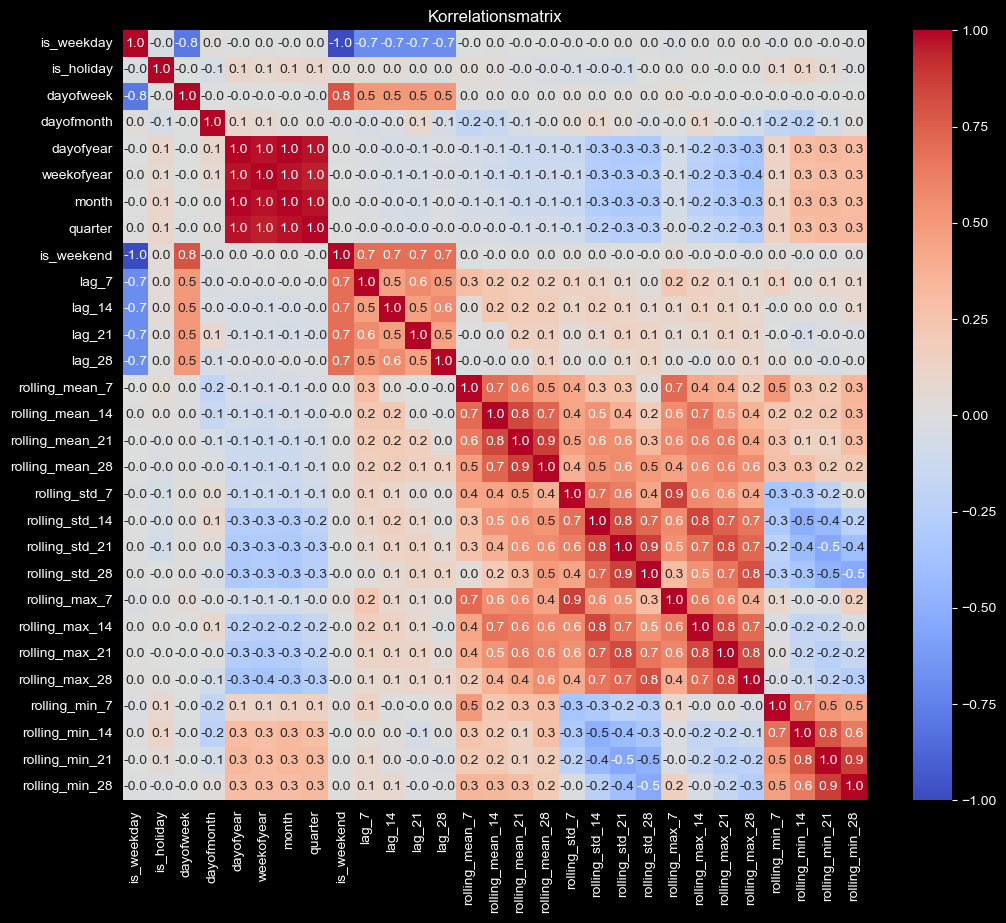

,is_weekday,is_holiday,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,is_weekend,lag_7,...,rolling_std_21,rolling_std_28,rolling_max_7,rolling_max_14,rolling_max_21,rolling_max_28,rolling_min_7,rolling_min_14,rolling_min_21,rolling_min_28
is_weekday,1.000000,-0.046333,-0.790395,0.018385,-0.002062,0.003100,-0.003627,0.007413,-1.000000,-0.689565,...,0.001088,0.001427,-0.035160,0.006343,0.005860,0.008261,-0.026036,0.000681,-0.006348,-0.008510
is_holiday,-0.046333,1.000000,-0.005442,-0.050756,0.093275,0.064335,0.097600,0.091710,0.046333,0.032824,...,-0.080993,-0.004982,0.001860,0.011572,-0.000970,0.014606,0.084855,0.112958,0.053012,-0.022051
dayofweek,-0.790395,-0.005442,1.000000,-0.007093,-0.005881,-0.005824,-0.005298,-0.013616,0.790395,0.505530,...,0.009272,0.008516,0.040501,-0.003842,-0.002264,-0.004584,-0.001088,-0.009851,-0.002665,-0.000642
dayofmonth,0.018385,-0.050756,-0.007093,1.000000,0.088412,0.064172,0.008725,0.011107,-0.018385,-0.043515,...,0.025214,-0.044078,-0.000313,0.085046,-0.001078,-0.082930,-0.193883,-0.221639,-0.083431,0.021354
dayofyear,-0.002062,0.093275,-0.005881,0.088412,1.000000,0.975831,0.996792,0.970963,0.002062,-0.018548,...,-0.301661,-0.304974,-0.083683,-0.222820,-0.275591,-0.343968,0.131687,0.307520,0.326202,0.311991
weekofyear,0.003100,0.064335,-0.005824,0.064172,0.975831,1.000000,0.974511,0.952166,-0.003100,-0.024792,...,-0.291463,-0.286477,-0.066369,-0.240731,-0.290328,-0.356066,0.115910,0.289667,0.308491,0.305727
month,-0.003627,0.097600,-0.005298,0.008725,0.996792,0.974511,1.000000,0.973534,0.003627,-0.015207,...,-0.307395,-0.306354,-0.084955,-0.232053,-0.279007,-0.342338,0.147893,0.326411,0.334400,0.312448
quarter,0.007413,0.091710,-0.013616,0.011107,0.970963,0.952166,0.973534,1.000000,-0.007413,-0.014920,...,-0.250580,-0.257632,-0.042548,-0.160246,-0.204814,-0.267506,0.133290,0.293535,0.319759,0.318298
is_weekend,-1.000000,0.046333,0.790395,-0.018385,0.002062,-0.003100,0.003627,-0.007413,1.000000,0.689565,...,-0.001088,-0.001427,0.035160,-0.006343,-0.005860,-0.008261,0.026036,-0.000681,0.006348,0.008510
lag_7,-0.689565,0.032824,0.505530,-0.043515,-0.018548,-0.024792,-0.015207,-0.014920,0.689565,1.000000,...,0.065201,0.026106,0.221669,0.157764,0.115448,0.065390,0.142596,0.043352,0.081962,0.081684


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

X = time_series_added_features.drop(columns=['date', 'unit_sales'])
corr = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Korrelationsmatrix")
plt.show()

corr

In [6]:
# Hoch colineare features entfernen, da Problem für Linear Regression (XBoost hat dagegen KEIN Problem mit Colinearität!)

drop_cols = [
    "is_weekday",   # = Gegenteil von is_weekend
    "dayofyear",    # ≈ month (r=0.997)
    "quarter",      # ≈ month (r=0.974)
    "weekofyear",   # ≈ month (r=0.975)
    "rolling_max_7",
    "rolling_max_21",
    "rolling_max_28",
    "rolling_std_7",
    "rolling_std_21",
    "rolling_std_28",
    "rolling_min_7",
    "rolling_min_14",
    "rolling_min_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

time_series_ALL_features = time_series_added_features.copy()
time_series_added_features_reduced_colinearity = time_series_added_features.drop(columns=drop_cols)

# Extreme Gradient Boosting (XGBoost)
## Vorbereitung Splitting

In [7]:
# Zielvariable und Features definieren
y = time_series_ALL_features['unit_sales']

# Features definieren
X = time_series_ALL_features.drop(columns=['unit_sales', 'date'])

## Splitten in Trainings- und Testdaten
### Datum basierter Split

In [8]:
# (1d) Zeitraum-basierter Split
train_filter = time_series_ALL_features["date"] < "2014-01-01"
test_filter  = (time_series_ALL_features["date"] >= "2014-01-01") & \
               (time_series_ALL_features["date"] <= "2014-03-31")        # => Das "\" sagt dem Interpreter: „Die nächste Zeile gehört noch zu diesem Ausdruck."

X_train = X[train_filter]
y_train = y[train_filter]

X_test = X[test_filter]
y_test = y[test_filter]

### Prozentualer Split (nicht! randomisiert)

In [9]:
# Absolute Voraussetzung für diesen Ansatz: Daten sind chronologisch geordnet!!!!

# (a) Chronologisch ordnen
time_series_ALL_features = time_series_ALL_features.sort_values("date")

# (b) Randparameter festlegen
train_size = int(len(time_series_ALL_features) * 0.8)

# (c) Splitten
train, test = time_series_ALL_features[:train_size], time_series_ALL_features[train_size:]

# das kann man auch für mich gewohnter coden:
train = time_series_ALL_features[:train_size]
test = time_series_ALL_features[train_size:]

### Rollendes Fenster Train-Test-Split (Backtesting)

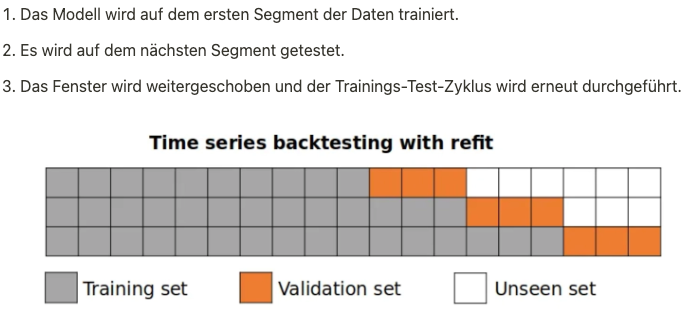

In [10]:
# Beispiel für einen Rolling Window Split in Python mit TimeSeriesSplit
## Dieses Bsp hat also nix mit meinen Daten hier zu tun. Code nur zum Anschauen!
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit()
for train_index, test_index in tscv.split(time_series_ALL_features):
    train = time_series_ALL_features.iloc[train_index]
    test = time_series_ALL_features.iloc[test_index]
    # Trainiere das Modell auf `train` und teste es auf `test`

## Modell definieren & trainieren & Forecasten & plotten
### Basis Datum/Prozentualer Split

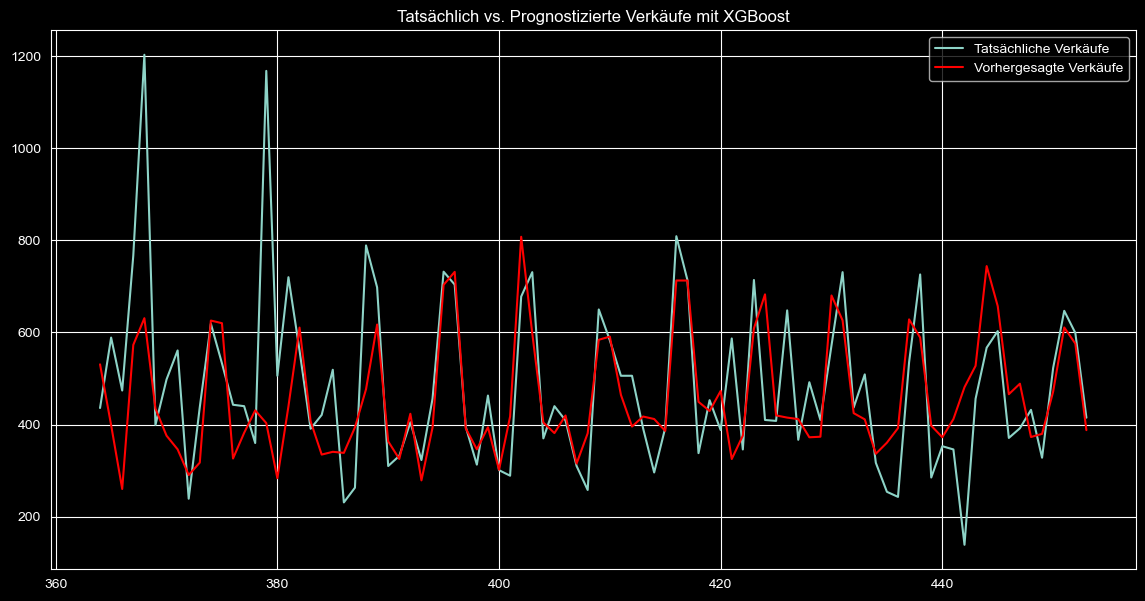

In [11]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# XGBoost Regressor initialisieren
xgboost_model = xgb.XGBRegressor(random_state=42)

# Modell trainieren
xgboost_model.fit(X_train, y_train)

# Prognosen für Testdaten erstellen
y_pred = xgboost_model.predict(X_test)

# Tatsächliche vs. Vorhergesagte Werte visualisieren
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Tatsächliche Verkäufe')
plt.plot(y_test.index, y_pred, label='Vorhergesagte Verkäufe', color='red')
plt.title('Tatsächlich vs. Prognostizierte Verkäufe mit XGBoost')
plt.legend()
plt.show()


### Basis = Rollendes Fenster während Split => Code von KI

Fold 1: MAE = 115.51


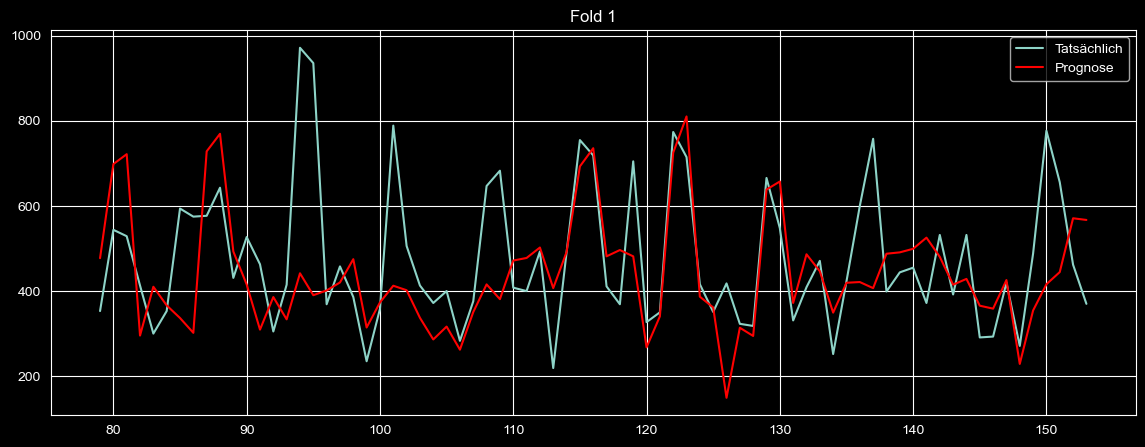

Fold 2: MAE = 96.76


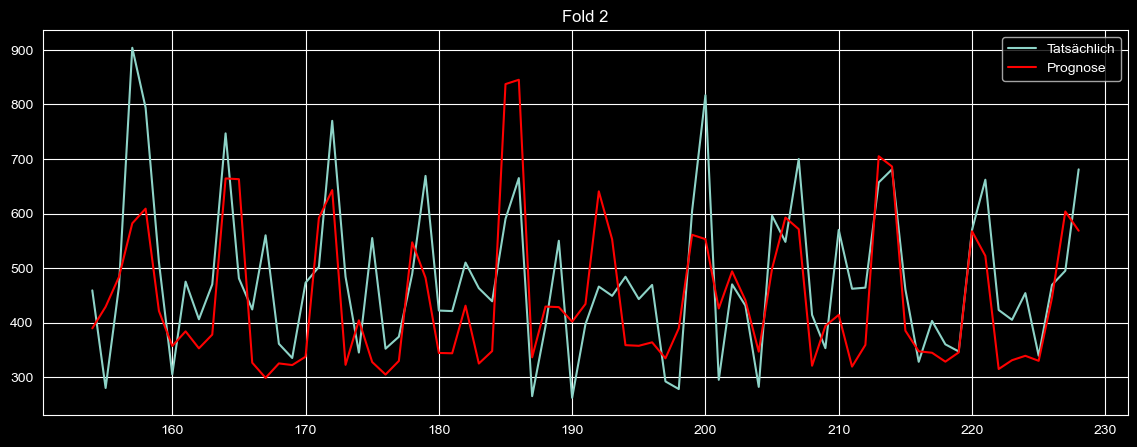

Fold 3: MAE = 105.10


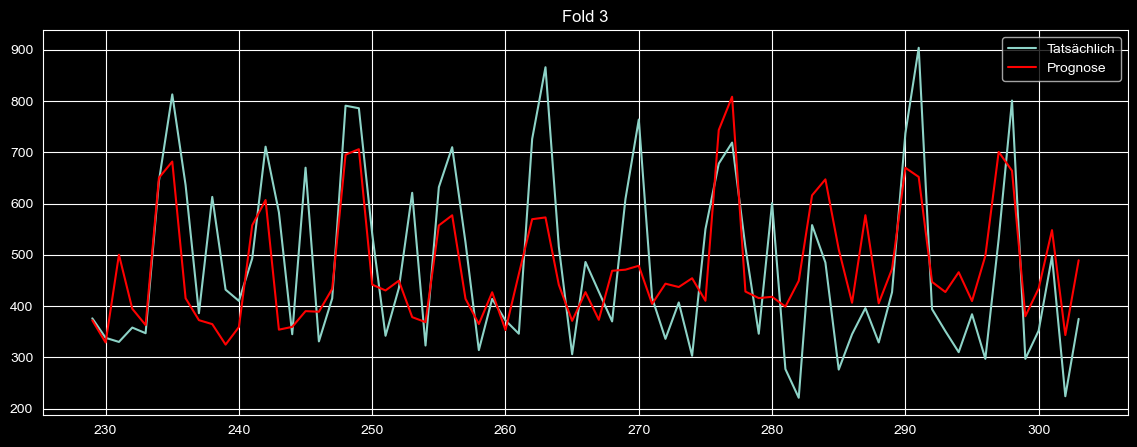

Fold 4: MAE = 99.52


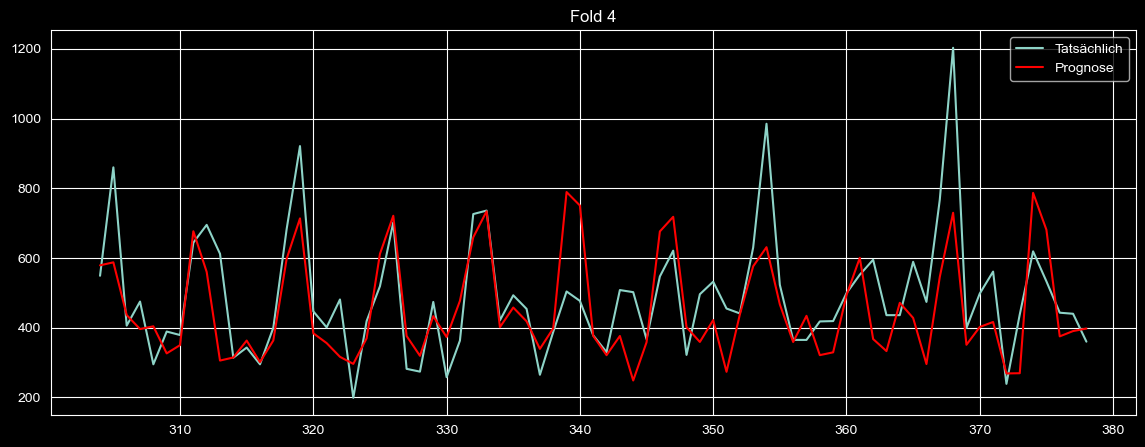

Fold 5: MAE = 107.05


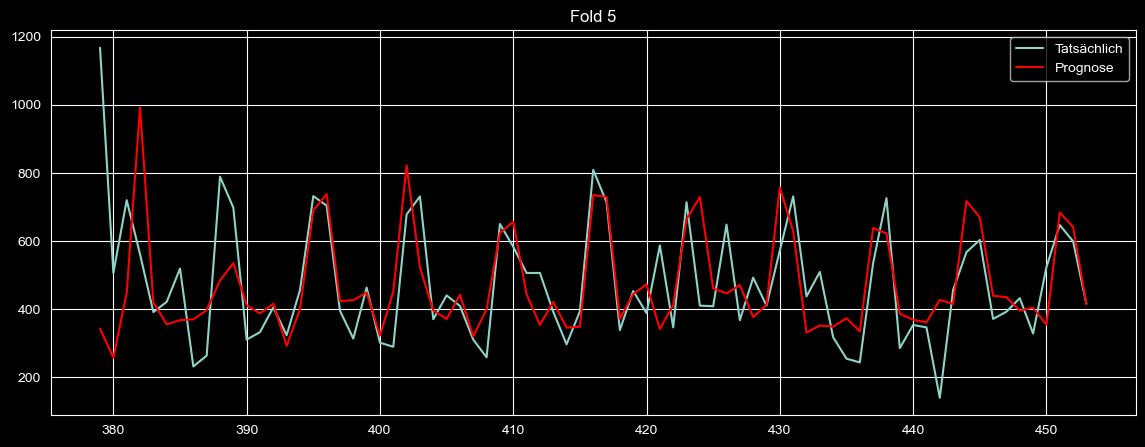


Mittlerer MAE über alle Folds: 104.79


In [12]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

# Zielspalte und Features definieren (date und target ausgeschlossen)
target = "unit_sales"
features = [col for col in time_series_ALL_features.columns if col not in [target, "date"]]

# TimeSeriesSplit mit 5 Folds initialisieren
tscv = TimeSeriesSplit(n_splits=5)

# Liste zum Speichern des MAE pro Fold
results = []

for fold, (train_index, test_index) in enumerate(tscv.split(time_series_ALL_features)):

    # Daten anhand der Fold-Indizes aufteilen (rolling-Suffix zur sauberen Trennung vom zeitraum-basierten Split)
    train_rolling = time_series_ALL_features.iloc[train_index]
    test_rolling  = time_series_ALL_features.iloc[test_index]

    # Features und Zielvariable trennen
    X_train_rolling, y_train_rolling = train_rolling[features], train_rolling[target]
    X_test_rolling,  y_test_rolling  = test_rolling[features],  test_rolling[target]

    # Modell initialisieren und auf Trainingsdaten dieses Folds trainieren
    xgboost_model = xgb.XGBRegressor(random_state=42)
    xgboost_model.fit(X_train_rolling, y_train_rolling)

    # Vorhersagen für den Testbereich dieses Folds erstellen
    y_pred_rolling = xgboost_model.predict(X_test_rolling)

    # MAE berechnen und speichern
    mae = mean_absolute_error(y_test_rolling, y_pred_rolling)
    results.append(mae)
    print(f"Fold {fold+1}: MAE = {mae:.2f}")

    # Tatsächliche vs. vorhergesagte Werte pro Fold plotten
    plt.figure(figsize=(14, 5))
    plt.plot(y_test_rolling.index, y_test_rolling.values, label="Tatsächlich")
    plt.plot(y_test_rolling.index, y_pred_rolling, label="Prognose", color="red")
    plt.title(f"Fold {fold+1}")
    plt.legend()
    plt.show()

# Durchschnittlicher MAE über alle Folds als finale Modellbewertung
print(f"\nMittlerer MAE über alle Folds: {sum(results)/len(results):.2f}")

## Evaluation

In [13]:
# Erstellen der Funktion zur Berechnung der Metriken => Code von MasterSchool
import numpy as np

def forecast_metrics(y_true, y_pred):
    """
    Berechne eine gemeinsame Menge an Prognose-Fehlerstatistiken.

    Parameter
    ----------
    y_true : 1-D array-like
        Tatsächliche (Ground-Truth) Werte.
    y_pred : 1-D array-like
        Prognostizierte Werte.

    Rückgabe
    -------
    dict
        Schlüssel: 'MAE', 'Bias', 'MAD', 'rMAD', 'MAPE', 'RMSE'
    """
    y_true = np.asarray(y_true, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()

    # Basis-Fehlerberechnungen
    errors       = y_true - y_pred
    abs_errors   = np.abs(errors)
    pct_errors   = abs_errors / np.where(y_true == 0, np.nan, y_true)   # ÷0 vermeiden

    # Kernstatistiken
    mae   = abs_errors.mean()
    bias  = errors.mean()
    rmse  = np.sqrt((errors ** 2).mean())

    # MAD der tatsächlichen Serie (Streuung der Nachfrage selbst)
    mad   = np.abs(y_true - y_true.mean()).mean()

    # Relative MAD = MAE geteilt durch MAD  (wie groß der Prognosefehler im Vergleich zur "typischen" Schwankung ist)
    rmad  = mae / mad if mad else np.nan

    # Mean Absolute Percentage Error
    mape  = np.nanmean(pct_errors) * 100   # ausgedrückt in %

    return {
        "MAE" : mae,
        "Bias": bias,
        "MAD" : mad,
        "rMAD": rmad,
        "MAPE": mape,
        "RMSE": rmse
    }


In [14]:
metrics = forecast_metrics(y_test, y_pred)

for k, v in metrics.items():
    print(f"{k}: {v:,.2f}")

MAE: 102.99
Bias: 25.50
MAD: 141.25
rMAD: 0.73
MAPE: 22.54
RMSE: 153.71


Das baseline XGBoost-Modell macht einen soliden, aber nicht herausragenden Job:
- MAE ≈ 107 Einheiten
    - an Tagen mit typischerweise 300-800 Einheiten liegt das Modell im Durchschnitt etwa um eine Kommissionier-Box pro vierhundert bis fünfhundert Einheiten daneben.

- Bias = 4 Einheiten
    - die Vorhersagen liegen im Durchschnitt leicht zu hoch

- RMSE ≈ 160 Einheiten > MAE
    - der höhere RMSE zeigt, dass einige wenige Tage mit großen Nachfragespitzen immer noch große quadratische Fehler verursachen; das Modell hat die höchsten Spitzen noch nicht gelernt.

- MAD ≈ 140 Einheiten
    - → rMAD = 0.76 – der Fehler beträgt etwa 76 % der eigenen täglichen Variabilität der Serie, das Modell erfasst also den Großteil, aber nicht die gesamte natürliche Streuung.

- MAPE ≈ 24 %
    - ein durchschnittlicher relativer Fehler von etwa einem Viertel tatsächlichen Bedarfs, was im Einzelhandel akzeptabel ist, aber noch Raum für Verbesserungen lässt.

# Forecasting Approaches am Bsp XGBoost

- Test und Trainingsdaten schon vorhanden!
- die Daten aus den rollenden Fenster hatte ich train_rolling und test_rolling genannt, damit hier nix durcheinander läuft im Skript

## Einfaches Forecasting

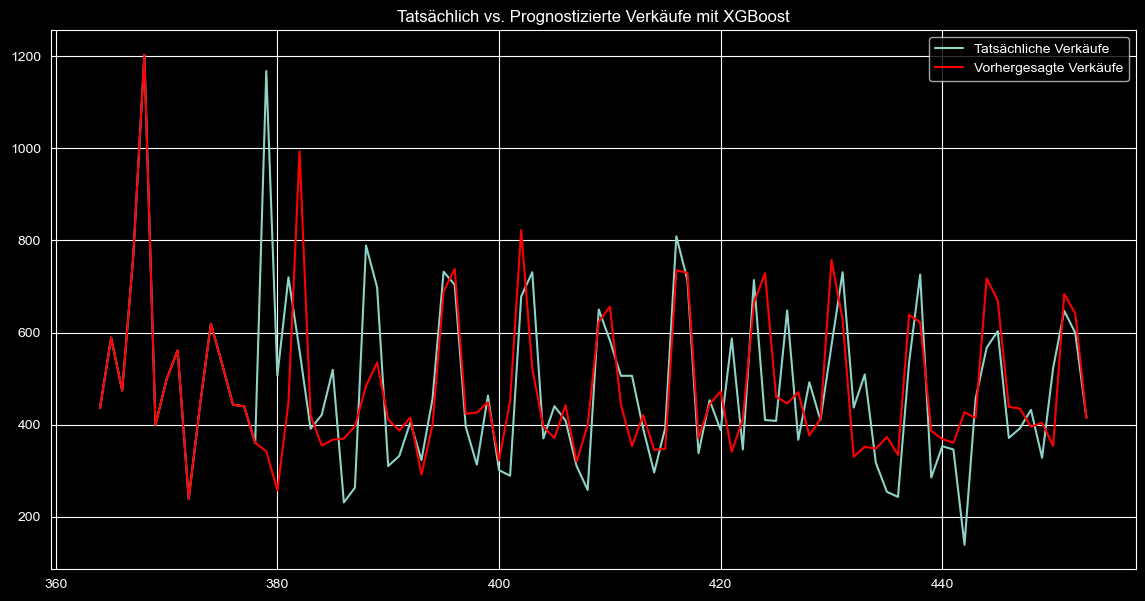

In [15]:
# Ganz normal, wie gehabt
# Prognosen für Testdaten erstellen
y_pred = xgboost_model.predict(X_test)

# Tatsächliche vs. Vorhergesagte Werte visualisieren
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Tatsächliche Verkäufe')
plt.plot(y_test.index, y_pred, label='Vorhergesagte Verkäufe', color='red')
plt.title('Tatsächlich vs. Prognostizierte Verkäufe mit XGBoost')
plt.legend()
plt.show()

## Iteratives Forecasting

In [16]:
train_df = train.set_index("date")
history = train_df["unit_sales"].copy()
forecasts = []
last_date = history.index[-1]
next_date = last_date + pd.Timedelta(days=1)
next_date

Timestamp('2014-01-16 00:00:00')

### Folgender Code von MasterSchool nicht abgestimmt auf meine Features

In [17]:
"""
def iterative_forecast(xgboost_model, train, n_future_days):
    train_df = train_df.set_index("date")
    # Work on a copy so we don't mutate the original
    history = train_df["unit_sales"].copy()

    forecasts = []
    last_date = history.index[-1]

    for i in range(1, n_future_days + 1):
        next_date = last_date + pd.Timedelta(days=i)

        # --- Lag features ---
        lag_1  = history.iloc[-1]
        lag_7  = history.iloc[-7]  if len(history) >= 7  else history.iloc[0]
        lag_30 = history.iloc[-30] if len(history) >= 30 else history.iloc[0]

        # --- Rolling average (last 2 values) ---
        rolling_avg_2 = history.iloc[-2:].mean()

        # --- Calendar features ---
        day_of_week = next_date.dayofweek          # 0 = Monday … 6 = Sunday
        is_weekend  = int(day_of_week >= 5)

        # --- Build the feature row (column order must match training) ---
        row = pd.DataFrame({
            "lag_1":          [lag_1],
            "lag_7":          [lag_7],
            "lag_30":         [lag_30],
            "rollings_avg_2": [rolling_avg_2],
            "day_of_week":    [day_of_week],
            "is_weekend":     [is_weekend],
        })

        # --- Predict and store ---
        yhat = model.predict(row)[0]
        forecasts.append({"date": next_date, "unit_sales": yhat})

        # --- Append prediction to history so next iteration can use it ---
        history.loc[next_date] = yhat

    return pd.DataFrame(forecasts)


forecast = iterative_forecast(xgboost_model, train, len(X_test))
forecast

"""

'\ndef iterative_forecast(xgboost_model, train, n_future_days):\n    train_df = train_df.set_index("date")\n    # Work on a copy so we don\'t mutate the original\n    history = train_df["unit_sales"].copy()\n\n    forecasts = []\n    last_date = history.index[-1]\n\n    for i in range(1, n_future_days + 1):\n        next_date = last_date + pd.Timedelta(days=i)\n\n        # --- Lag features ---\n        lag_1  = history.iloc[-1]\n        lag_7  = history.iloc[-7]  if len(history) >= 7  else history.iloc[0]\n        lag_30 = history.iloc[-30] if len(history) >= 30 else history.iloc[0]\n\n        # --- Rolling average (last 2 values) ---\n        rolling_avg_2 = history.iloc[-2:].mean()\n\n        # --- Calendar features ---\n        day_of_week = next_date.dayofweek          # 0 = Monday … 6 = Sunday\n        is_weekend  = int(day_of_week >= 5)\n\n        # --- Build the feature row (column order must match training) ---\n        row = pd.DataFrame({\n            "lag_1":          [lag_1

### Folgender Code abgestimmt auf meine Features (KI...)

In [18]:
def iterative_forecast(model, train, features, target, n_future_days):

    # Historische Zeitreihe als Basis für Lag-Berechnung
    history = train.set_index("date")[target].copy()

    forecasts = []
    last_date = history.index[-1]

    for i in range(1, n_future_days + 1):
        next_date = last_date + pd.Timedelta(days=i)

        row = {}
        for col in features:

            # Lag-Features: lag_1, lag_7, lag_30 etc. => Zahl aus Spaltenname lesen
            if col.startswith("lag_"):
                n = int(col.split("_")[1])
                row[col] = history.iloc[-n] if len(history) >= n else history.iloc[0]

            # Rolling-Features: rolling_avg_2, rolling_avg_7 etc. => Fenstergröße aus Name lesen
            elif "rolling" in col:
                n = int(col.split("_")[-1])
                row[col] = history.iloc[-n:].mean()

            # Kalender-Features
            elif col == "day_of_week":
                row[col] = next_date.dayofweek
            elif col == "is_weekend":
                row[col] = int(next_date.dayofweek >= 5)
            elif col == "month":
                row[col] = next_date.month
            elif col == "day":
                row[col] = next_date.day

            # Fallback: letzten bekannten Wert nehmen (z.B. statische Features)
            else:
                row[col] = train[col].iloc[-1]

        # Feature-Reihenfolge muss exakt mit Training übereinstimmen
        X_row = pd.DataFrame([row])[features]
        yhat = model.predict(X_row)[0]
        forecasts.append({"date": next_date, target: yhat})

        # Vorhersage zur History hinzufügen => nächste Iteration nutzt diesen Wert
        history.loc[next_date] = yhat

    return pd.DataFrame(forecasts)

In [19]:
forecast_df = iterative_forecast(
    model=xgboost_model,
    train=train_rolling,       # letzter Fold oder dein zeitraum-basierter Train-Split
    features=features,
    target=target,
    n_future_days=len(test_rolling)
)

In [20]:
forecast_df.head(4)

,date,unit_sales
0,2014-01-16,443.163666
1,2014-01-17,453.052368
2,2014-01-18,459.018402
3,2014-01-19,481.770477


In [21]:
forecast_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        75 non-null     datetime64[us]
 1   unit_sales  75 non-null     float32       
dtypes: datetime64[us](1), float32(1)
memory usage: 1.0 KB


## Plotting

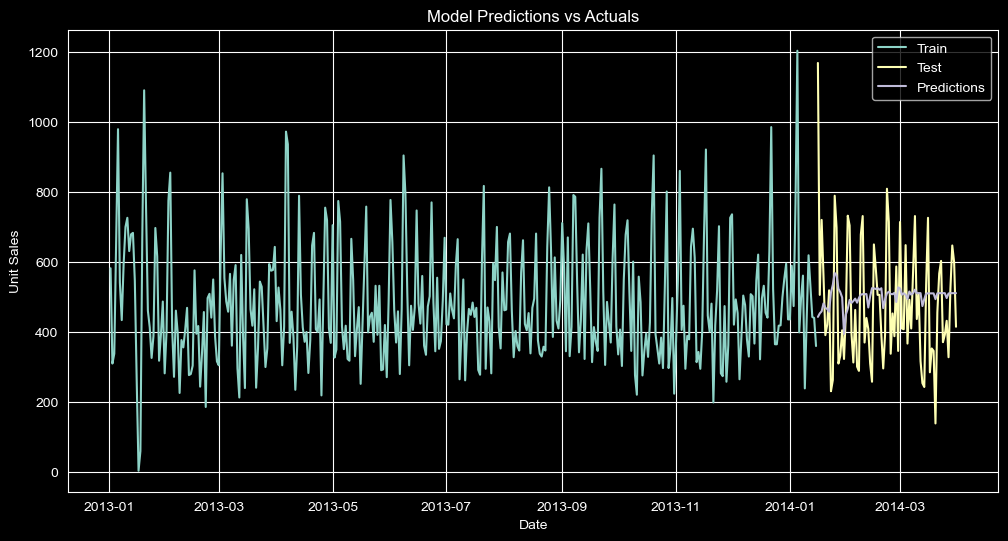

In [22]:
y_pred = forecast_df["unit_sales"]

plt.figure(figsize=(12, 6))
plt.plot(train['date'], train['unit_sales'], label='Train')
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()

## Evaluation

In [23]:
# Echte Testwerte auf den Forecast-Zeitraum einschränken
y_true_iter = test_rolling.set_index("date")[target].loc[forecast_df["date"].values]
y_pred_iter = forecast_df.set_index("date")[target]

# Metriken berechnen (Funktion weiter oben selbst entworfen (bzw. von MasterSchool))
metrics = forecast_metrics(y_true_iter, y_pred_iter)

# Ausgabe
for name, value in metrics.items():
    print(f"{name:>6}: {value:.3f}")

   MAE: 143.822
  Bias: -25.834
   MAD: 140.825
  rMAD: 1.021
  MAPE: 36.388
  RMSE: 177.789
